In [2]:

import os

import numpy as np
from pylab import *

import glob
import numba
from craft import calc11
from craco import metadatafile

from numba import jit,njit,prange
import astropy.units as u
from astropy.coordinates import AltAz, EarthLocation, SkyCoord
from astropy.time import Time
from craft.calc11 import uvw_ant_to_baselines


%matplotlib notebook
%load_ext autoreload
%autoreload 2

In [4]:
ls *.npys

boxcar_hist_iblk0.npy  boxcar_hist_iblk1.npy


In [114]:
d = np.load('/data/craco/ban115/craco-python/notebooks/data/B1933+16/SB049048v2/widthtest/boxcar_hist_iblk0.npy')
d = d[:,:,:,:]

In [115]:

stdvdm = d.std(axis=(1,2,3))

d.shape

(1024, 7, 256, 256)

In [116]:
d2 = np.load('/data/craco/ban115/craco-python/notebooks/data/SB049048v2/cap_spi16_bm0_a1-12_k1-6_ps_tsoff/results/boxcar_hist_iblk0.npy')

In [117]:
stdvdm2 = d2.std(axis=(1,2,3))

In [118]:
from craft import uvfits

In [119]:
from astropy.io import fits

uvin = uvfits.UvFits(fits.open('/data/craco/ban115/craco-python/notebooks/data/SB049048v2/cap_spi16_bm0_a1-12_k1-6_ps_tsoff/results/b00.uvfits'))

In [120]:
freqs = uvin.channel_frequencies/1e9
nchan = len(freqs)
foff = (freqs[1] - freqs[0])
fch1 = freqs[0]
max_dt = 1024
nt=256

In [121]:
nchan

48

In [122]:
foff

0.0010000000000000009

In [123]:
fch1

0.7429907407407407

In [124]:
from craft import fdmt
thefdmt = fdmt.Fdmt(fch1, foff, nchan, max_dt, nt)

In [138]:
sigma = np.array([thefdmt.get_eff_sigma(idt, 1) for idt in range(max_dt)])


In [139]:
ind = np.random.randn(nt*nchan).reshape(nchan,nt)
ind = np.ones((nchan,nt))
outd = thefdmt(ind)
outd.shape

(1024, 1280)

In [141]:
nhits = outd[:,nt-1]

<IPython.core.display.Javascript object>


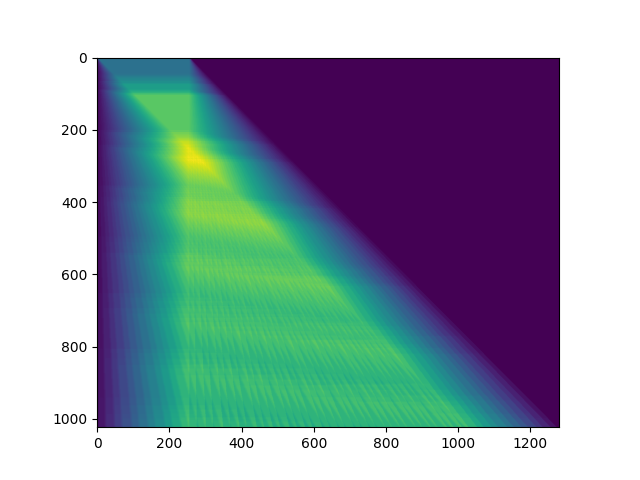

In [142]:
figure()
imshow(outd)

<IPython.core.display.Javascript object>


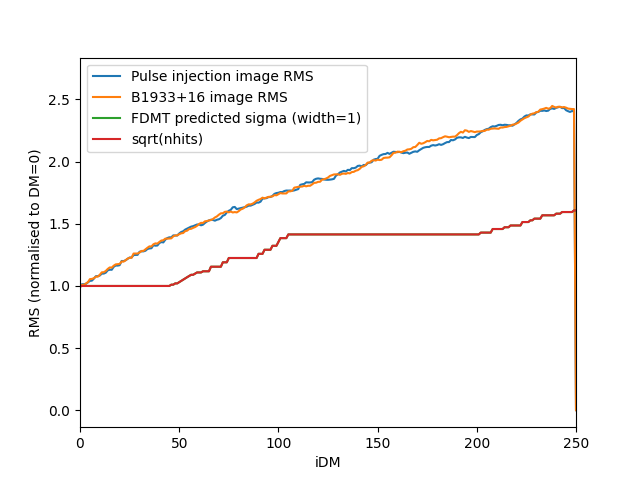

In [145]:
figure()
plot(stdvdm/18, label='Pulse injection image RMS')
plot(stdvdm2/18, label='B1933+16 image RMS')
plot(sigma/np.sqrt(nchan), label='FDMT predicted sigma (width=1)')
plot(np.sqrt(nhits/nchan), label='sqrt(nhits)')
xlabel('iDM')
ylabel('RMS (normalised to DM=0)')
xlim(0,250)
legend()

In [127]:
tsamp = 0.86
fend = fch1 + foff*nchan
dm = 158
tdelay = 4.15*dm*(fch1**-2 - fend**-2)
tdelay

139.78382984726915

In [128]:
tdelay/tsamp

162.5393370317083